## Plot analysis of the interaction

Plotting the interaction as a sequence of signals can help providing insight in the quality of the interaction.
The ```plot_interaction.py``` script has a function ```create_timeline_image``` to plot the interaction as a sequence.
The function takes as parameters the path to EMISSOR and the scenario id. If the scenario id is omitted all scenarios in the emissor folder will be processed.
The ```create_timeline_image``` function saves the plot in an ```evaluation``` subfolder in the scenario folder. It also show the plot on the screen.

When plotting utterances and perceptions of each interlocutor on a timeline, we can also provide additional labels and scores for each signal. 
By scoring the signals positive and negative patterns of the inertaction are visualised. The scores are based on annotations of the signals.
Without such annotations, the interaction is visualised as a flat line in time. 

Details on how to annotate the EMISSOR scenarios can be found in the [cltl-emissor-annoation](https://github.com/leolani/cltl-emissor-annotation) module.
Currently, the following annotations can be used:

* Dialog acts mapped to positive and negative turns:

```
    negative = ['neg_answer', 'complaint', 'abandon', 'apology','non-sense', 'hold']
    positive = ['pos_answer', 'back-channeling', 'appreciation', 'thanking', 'respond_to_apology']
```
* GO emotions mapped to popsitive and negative turns:
```
    negative = ['remorse', 'nervousness', 'fear', 'sadness', 'embarassment', 'disappointment', 'grief', 'disgust', 'anger', 'annoyance', 'disapproval', 'confusion']
    positive = ['joy', 'amusement','excitement', 'love', 'desire', 'optimism', 'caring', 'pride', 'admiration', 'gratitude', 'belief', 'approval', 'curiosity']
```
* EKMAN's basic emotions mapped to positive and negative turns:
```
negative = ["anger", "disgust", "fear", "sadness"]
positive = ["joy"]
```
* Positive and negative sentiments
* The log likelihood score of the utterance mapped to positive and negative scores

The ```text_signal.py``` script defines the mappings. You can adapt this script to get another mapping.
You can also use the class ```PlotSettings``` to further finetune how the annoations are mapped to the plot:

* _ANNOTATIONS: string that contains the annotations used to score each signal: this can be dialog_act, 'go', 'ekman', 'sentiment' or 'llh' 
* _SENTIMENT_THRESHOLD: threshold for the confidence score of an annotation to be used for scoring
* _LLH_THRESHOLD: threshold below which a likelihood score is considered negative and above which it is considered positive

The y-axis of the plot ranges from -5 till 5. Any annotation that is considered to positively contribute adds positively to score whereas negative annotations add negatively. 
Neutral labels do not alter the score. To contribute, the dialogue act/emotion/sentiment label needs to have a confidence score above the ```_SENTIMENT_THRESHOLD```.

The liklihood score can also contribute positively and negatively to the score to the extend that the are below or above the ```_LLH_THRESHOLD```. 
If the threshold is set to ```0.5``` a LLH of ```0.6``` will contribute ```0.6-0.5=0.1```  as a positive score. If the LLH is ```04```, it contributes ```04-05=-01``` as a negative score.

Through the parameter ```_ANNOTATIONS``` you can choose what will be used to score a signal: ```dialog_acts``` = only dialog acts, ```go,llh``` = only GO emotions and likelihood, ```ekman, sentiment, go``` = all three emotion/sentiment values and no likelihood.

Finally, you can set START and END point of the interaction that needs to be plotted.

# Prerequisites

The following packages need to be installed in addition to the local code. These packages can be installed through the ```requirements.txt```.

In [1]:
# !pip install seaborn
# !pip install matplotlib
# !pip install pandas
# !pip install emissor

## Generating the plot for a single scenario

In [17]:
import plot_interaction as plot
from emissor.persistence import ScenarioStorage
from emissor.persistence.persistence import ScenarioController
from emissor.processing.api import SignalProcessor
from emissor.representation.scenario import Modality, Signal

In [2]:
EMISSOR="../emissor"
SCENARIO="b387db06-934e-405b-9d4e-f7e5c27b440a"

Nr of signals 9


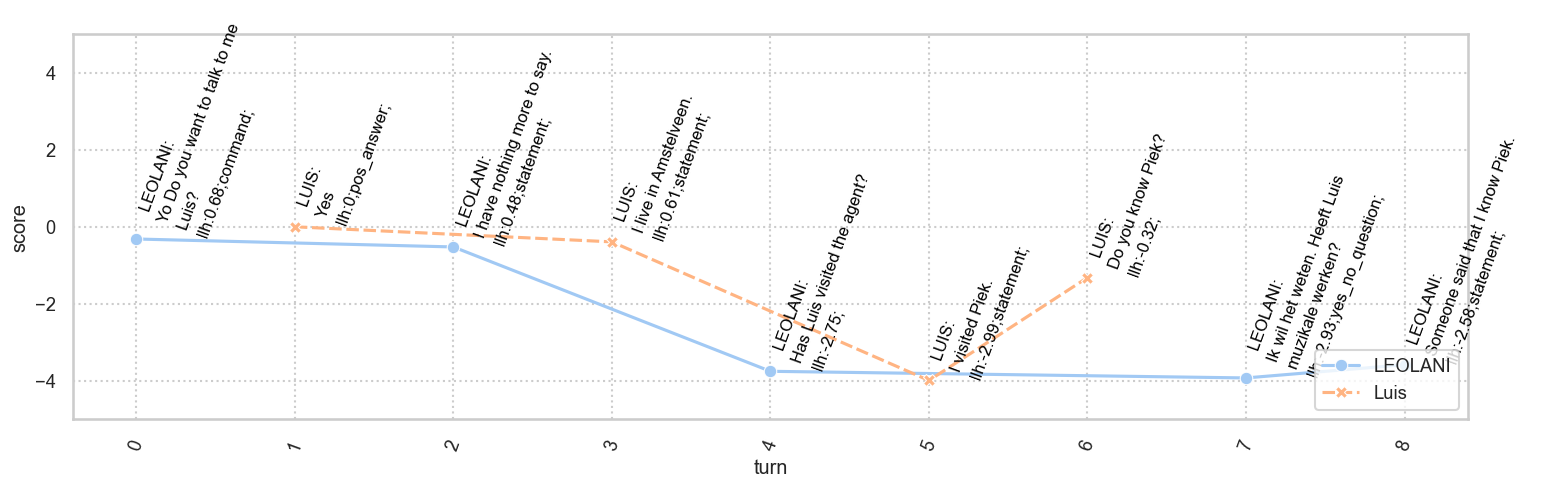

In [6]:
## Plot analysis

settings = plot.PlotSettings()
settings._ANNOTATIONS = 'go,sentiment,llh'
settings._ANNOTATIONS = 'dialog_acts, llh'
settings._ANNOTATIONS = 'llh'
settings._SENTIMENT_THRESHOLD=0.5
settings._LLH_THRESHOLD=0.4
settings._START=0  
settings._END=-1  

plot.create_timeline_image(emissor_path=EMISSOR, 
                           scenario=SCENARIO,
                           settings=settings)

In [18]:
EMISSOR="../emissor"
#### The next scenario is created by interacting with the Ai2Thor platform.
SCENARIO="0985799c-80eb-416c-b55e-f11ffc4ac259"

Nr of signals 26


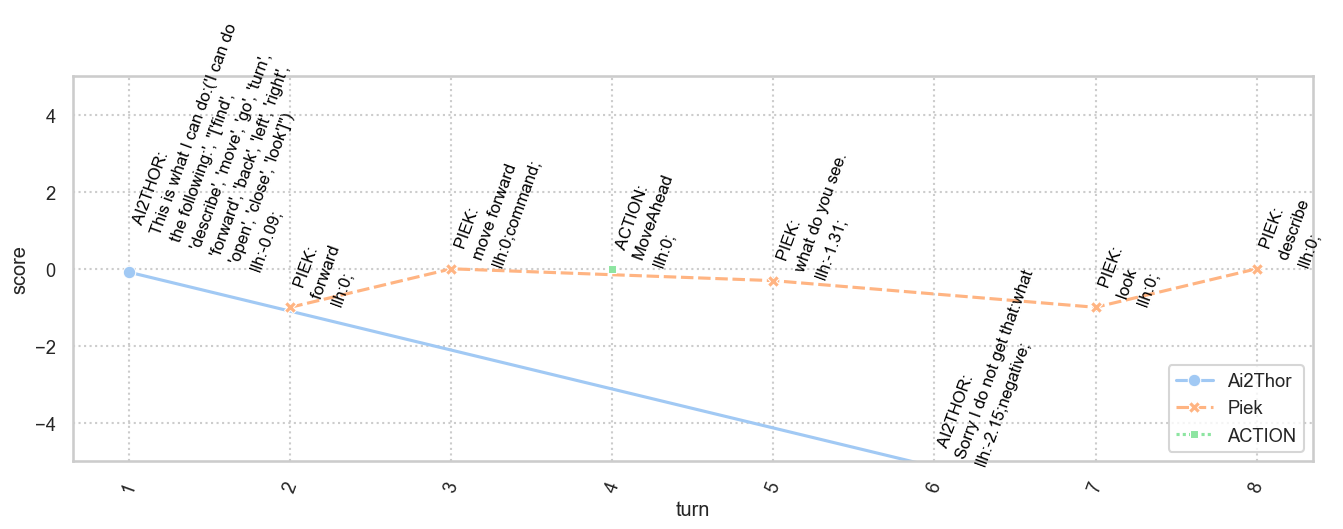

In [20]:
## Plot analysis

settings = plot.PlotSettings()
settings._ANNOTATIONS = 'dialog_acts,go,sentiment,llh'
settings._SENTIMENT_THRESHOLD=0.7
settings._LLH_THRESHOLD=0.3
settings._START=1
settings._END=8

plot.create_timeline_image(emissor_path=EMISSOR, 
                           scenario=SCENARIO,
                           settings=settings)

## End of notebook